In [121]:
import Circuit as c
import numpy as np
import GateGeneration as gg
import matplotlib.pyplot as plt
from scipy.linalg import expm, norm

In [198]:
#functions to define each pauli string
x = np.array([[0, 1],
              [1, 0]], dtype=complex)
y = np.array([[0, -1j],
              [1j, 0]], dtype=complex)
z = np.array([[1, 0],
              [0, -1]], dtype=complex)
I = np.array([[1, 0],
              [0, 1]], dtype=complex)

def pauli3(NIons, q1, q2, q3, gate1, gate2, gate3, coeff):
    gate = np.array([1], dtype=complex)
    for i in range(NIons):
        if q1 == i:
            gate = np.kron(gate, gate1)
        elif q2 == i:
            gate = np.kron(gate, gate2)
        elif q3 == i:
            gate = np.kron(gate, gate3)
        else:
            gate = np.kron(gate, I)
    gate = gate * coeff
    return gate


def pauli2(NIons, q1, q2, gate1, gate2, coeff):
    gate = np.array([1], dtype=complex)
    for i in range(NIons):
        if q1 == i:
            gate = np.kron(gate, gate1)
        elif q2 == i:
            gate = np.kron(gate, gate2)
        else:
            gate = np.kron(gate, I)
    gate = gate * coeff
    return gate
def pauli1(NIons, q, gate1, coeff):
    gate = np.array([1], dtype=complex)
    for i in range(NIons):
        if q == i:
            gate = np.kron(gate, gate1)
        else:
            gate = np.kron(gate, I)
    gate = gate * coeff
    return gate


#define all pauli strings
paulis = []
paulis.append(pauli2(4, 0, 1, x, x, 0.5)) #X(0) @ X(1): 0.5
paulis.append(pauli2(4, 0, 1, y, y, 0.5)) #Y(0) @ Y(1): (0.5+0j)
paulis.append(pauli2(4, 1, 2, x, y, -0.5)) #X(1) @ Y(2): (-0.5+0j)
paulis.append(pauli2(4, 1, 2, y, x, 0.5)) # Y(1) @ X(2): (0.5+0j)
paulis.append(pauli3(4, 1, 2, 3, x, y, x, 0.5)) # X(1) @ X(3): 0.5
paulis.append(pauli3(4, 1, 2, 3, y, z, y, 0.5)) # Y(1) @ Y(3): (0.5+0j)
paulis.append(pauli3(4, 0, 1, 2, x, z, x, 0.5)) # X(0) @ X(2): 0.5
paulis.append(pauli3(4, 0, 1, 2, y, z, y, 0.5)) # Y(0) @ Y(2): (0.5+0j)
paulis.append(pauli2(4, 2, 3, x, x, 0.5)) # X(2) @ X(3): 0.5
paulis.append(pauli2(4, 2, 3, y, y, 0.5)) # Y(2) @ Y(3): (0.5+0j)
paulis.append(pauli1(4, 0, I, 1.5)) # I(): 1.5
paulis.append(pauli1(4, 1, z, 0.75)) # Z(1): 0.75
paulis.append(pauli1(4, 0, z, 0.75)) # Z(0): 0.75
paulis.append(pauli2(4, 0, 1, z, z, 0.25)) # Z(0) @ Z(1): 0.25
paulis.append(pauli1(4, 2, z, 0.75)) # Z(2): 0.75
paulis.append(pauli2(4, 0, 2, z, z, 0.25)) # Z(0) @ Z(2): 0.25
paulis.append(pauli1(4, 3, z, 0.75)) # Z(3): 0.75
paulis.append(pauli2(4, 0, 3, z, z, 0.25)) # Z(0) @ Z(3): 0.25
paulis.append(pauli2(4, 1, 2, z, z, 0.25)) # Z(1) @ Z(2): 0.25
paulis.append(pauli2(4, 1, 3, z, z, 0.25)) # Z(1) @ Z(3): 0.25
paulis.append(pauli2(4, 2, 3, z, z, 0.25)) # Z(2) @ Z(3): 0.25

#define Hamiltonian
H = np.zeros([16, 16], dtype=complex)
for pauli in paulis:
    H += pauli


In [199]:
#separate hamiltonian into trotterization steps
XXs = []
YYs = []
Diagonals = []
XYs = []

XXs.append(pauli2(4, 0, 1, x, x, 0.5)) #X(0) @ X(1): 0.5
XXs.append(pauli2(4, 0, 2, x, x, 0.5)) # X(0) @ X(2): 0.5
XXs.append(pauli2(4, 1, 3, x, x, 0.5)) # X(1) @ X(3): 0.5
XXs.append(pauli2(4, 2, 3, x, x, 0.5)) # X(2) @ X(3): 0.5

YYs.append(pauli2(4, 0, 1, y, y, 0.5)) #Y(0) @ Y(1): (0.5+0j)
YYs.append(pauli2(4, 0, 2, y, y, 0.5)) # Y(0) @ Y(2): (0.5+0j)
YYs.append(pauli2(4, 1, 3, y, y, 0.5)) # Y(1) @ Y(3): (0.5+0j)
YYs.append(pauli2(4, 2, 3, y, y, 0.5)) # Y(2) @ Y(3): (0.5+0j)

Diagonals.append(pauli1(4, 0, I, 1.5)) # I(): 1.5
Diagonals.append(pauli1(4, 0, z, 0.75)) # Z(0): 0.75
Diagonals.append(pauli1(4, 1, z, 0.75)) # Z(1): 0.75
Diagonals.append(pauli1(4, 2, z, 0.75)) # Z(2): 0.75
Diagonals.append(pauli1(4, 3, z, 0.75)) # Z(3): 0.75
Diagonals.append(pauli2(4, 0, 1, z, z, 0.25)) # Z(0) @ Z(1): 0.25
Diagonals.append(pauli2(4, 0, 2, z, z, 0.25)) # Z(0) @ Z(2): 0.25
Diagonals.append(pauli2(4, 0, 3, z, z, 0.25)) # Z(0) @ Z(3): 0.25
Diagonals.append(pauli2(4, 1, 2, z, z, 0.25)) # Z(1) @ Z(2): 0.25
Diagonals.append(pauli2(4, 1, 3, z, z, 0.25)) # Z(1) @ Z(3): 0.25
Diagonals.append(pauli2(4, 2, 3, z, z, 0.25)) # Z(2) @ Z(3): 0.25

XYs.append(pauli2(4, 1, 2, y, x, 0.5)) # Y(1) @ X(2): (0.5+0j)
XYs.append(pauli2(4, 1, 2, x, y, -0.5)) #X(1) @ Y(2): (-0.5+0j)

H_XX = np.zeros([16, 16], dtype=complex)
for XX in XXs:
    H_XX += XX
H_YY = np.zeros([16, 16], dtype=complex)
for YY in YYs:
    H_YY += YY
H_Diagonal = np.zeros([16, 16], dtype=complex)
for Diagonal in Diagonals:
    H_Diagonal += Diagonal

H_XY = np.zeros([16, 16], dtype=complex)
for XY in XYs:
    H_XY += XY



In [200]:
def unitary_evolution(state, H, t):
    """
    Computes the unitary evolution matrix U(t) = e^(-i H t)
    
    Parameters:
    H (numpy.ndarray): Hamiltonian matrix (can be complex).
    t (float): Evolution time.

    Returns:
    numpy.ndarray: The unitary evolution matrix U(t).
    """

    # Step 1: Eigen decomposition H = VDV^(-1)
    eigenvalues, eigenvectors = np.linalg.eig(H)  # Use eig() for general matrices

    # Step 2: Compute e^(-i * eigenvalues * t) for each eigenvalue
    exp_diag = np.diag(np.exp(-1j * eigenvalues * t))
    
    # Step 3: Reconstruct U = V e^(-iDt) V^(-1)
    U = eigenvectors @ exp_diag @ np.linalg.pinv(eigenvectors)
    
    state = U @ state
    return state

def build_unitary(H, t):
    
    U = expm(-1j * H * t)
    return U

def Trotter(Hs, n, t_step, NIons):
    U_final = np.eye(2**NIons, 2**NIons, dtype=complex)
    U_onestep = np.eye(2**NIons, 2**NIons, dtype=complex)

    for H in Hs:
        U = build_unitary(H, t_step/n)
        U_onestep = U_onestep @ U

    for i in range(n):
        U_final = U_final @ U_onestep
    return U_final


def unitary_fidelity(U_exact, U_approx):
    d = U_exact.shape[0]
    overlap = np.trace(U_exact.conj().T @ U_approx)  # Tr(U† V)
    fidelity = np.abs(overlap) / d
    return fidelity


is: [1, 4, 9, 16, 25, 36, 49, 64, 81]
fidelity: [0.00228635931968354, 0.12818916124951196, 0.3113102145010512, 0.3365870075347237, 0.3446815160500807, 0.3481736482374538, 0.3499653729052662, 0.3509983264690283, 0.3516460713871779]


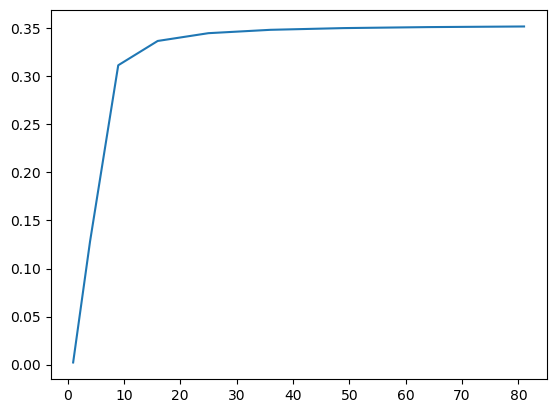

In [201]:
#plot difference between hamiltonian and trotterized approximation

Hs = [H_XX, H_Diagonal, H_YY, H_XY]
t = 3

trottersteps = []
fidelities = []
U = build_unitary(H, t)
for i in range(1, 10):
    Trottered_U = Trotter(Hs, i**2, t, 4)
    fidelity = unitary_fidelity(U, Trottered_U)
    fidelities.append(fidelity)
    trottersteps.append(i**2)
print("is:", trottersteps)
print("fidelity:", fidelities)
plt.plot(trottersteps, fidelities)





C:\Users\iontrap\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:18: ComplexWarning: Casting complex values to real discards the imaginary part


    9.187e-01+3.503e-01j    2.031e-02-2.558e-02j    1.277e-02-2.114e-02j    3.334e-02+1.153e-02j    3.464e-02+1.860e-02j   -9.168e-02-4.466e-02j    2.793e-02-5.678e-02j    3.157e-02-5.322e-02j    1.463e-02+1.287e-03j   -1.837e-02+1.214e-02j    2.326e-02-1.148e-02j   -3.185e-02+1.745e-03j   -2.303e-02-1.583e-04j    3.091e-02+1.769e-02j    2.167e-02+7.214e-02j    2.787e-02-5.951e-04j
   -2.634e-02-2.439e-02j    3.605e-01-1.815e-03j    1.499e-02+5.312e-02j    2.497e-01-1.781e-01j   -8.420e-02+6.826e-01j   -9.254e-02-8.551e-02j   -2.237e-01-6.861e-02j    1.978e-02-7.244e-02j   -2.485e-01+3.225e-02j    7.107e-02-1.133e-01j   -1.883e-01+6.308e-02j    2.518e-02-3.243e-02j    1.093e-01+2.065e-01j    5.828e-02+9.753e-02j    7.396e-02+1.129e-01j   -9.407e-02+7.706e-02j
    1.349e-02-3.265e-02j   -3.424e-02+2.504e-01j   -1.603e-01+9.831e-02j    9.400e-02+1.486e-01j   -8.785e-02+8.448e-02j   -1.972e-02-2.035e-01j   -2.231e-02-2.347e-01j   -7.445e-02+1.997e-02j   -3.373e-02+7.010e-01j   -1.590e-03+

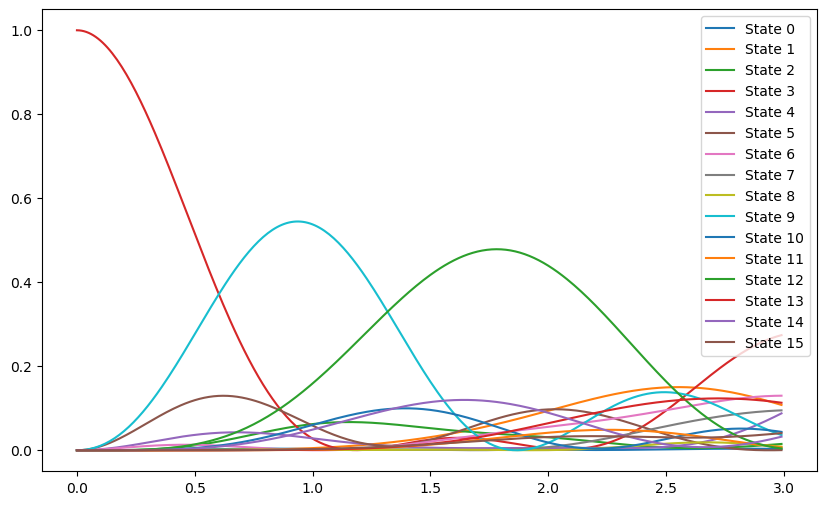

In [202]:
#plotting exact hamiltonian evolution

state = np.array([0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0], dtype=complex)

chances_true = np.zeros([300, 16])
chances_true[0][3] = 1
times = [0]

for i in range(1, 300):
    time = i / 100

    unitary = build_unitary(H, time)
    if i == 200:
        gg.print_matrix(unitary)
    newState = unitary @ state
    chance = []
    for j in range(16):
        chances_true[i][j] = (newState[j] * np.conjugate(newState[j]))

    times.append(time)

plt.figure(figsize=(10, 6))
for j in range(16):
    plt.plot(times, chances_true[:, j], label=f'State {j}')
plt.legend()

C:\Users\iontrap\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:20: ComplexWarning: Casting complex values to real discards the imaginary part


   -8.347e-01-4.273e-01j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j   -1.400e-02-5.359e-02j    0.000e+00+0.000e+00j    3.573e-02-8.864e-02j    1.586e-01+1.476e-01j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j    1.586e-01+1.476e-01j   -1.400e-02-5.359e-02j    0.000e+00+0.000e+00j    3.573e-02-8.864e-02j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j    3.696e-02+3.214e-02j
    0.000e+00+0.000e+00j    3.215e-01-6.623e-01j    3.078e-01+1.368e-01j    0.000e+00+0.000e+00j    1.681e-01+8.678e-02j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j    1.184e-01+1.700e-01j   -2.518e-02+2.757e-01j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j    2.816e-01+3.491e-02j    0.000e+00+0.000e+00j   -1.958e-02-2.557e-01j    1.184e-01+1.700e-01j    0.000e+00+0.000e+00j
    0.000e+00+0.000e+00j    2.783e-01+1.347e-01j    2.958e-01-5.282e-01j    0.000e+00+0.000e+00j    4.839e-04-3.355e-02j    0.000e+00+0.000e+00j    0.000e+00+0.000e+00j    2.394e-01-1.396e-02j    2.783e-01+1.347e-01j    0.000e+00+

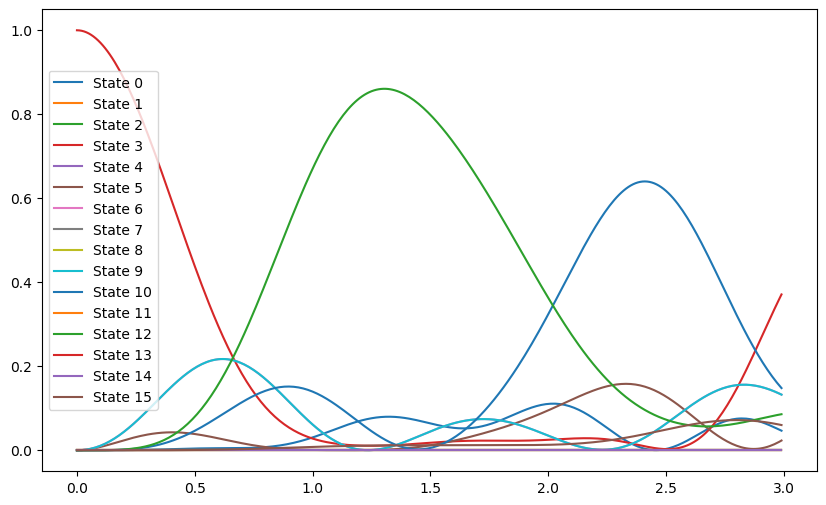

In [203]:
#plotting trotterized evolution

trottersteps = 6

state = np.array([0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0], dtype=complex)

chances_trottered = np.zeros([300, 16])
chances_trottered[0][3] = 1
times = [0]

for i in range(1, 300):
    time = i / 100
    Trottered_U = Trotter(Hs, trottersteps, time, 4)
    newState = (Trottered_U) @ state
    chance = []
    if i == 250:
        gg.print_matrix(Trottered_U)
        print(newState)
    for j in range(16):
        chances_trottered[i][j] = (newState[j] * np.conjugate(newState[j]))

    times.append(time)
gg.print_matrix(chances_trottered)
plt.figure(figsize=(10, 6))
for j in range(16):
    plt.plot(times, chances_trottered[:, j], label=f'State {j}')
plt.legend()



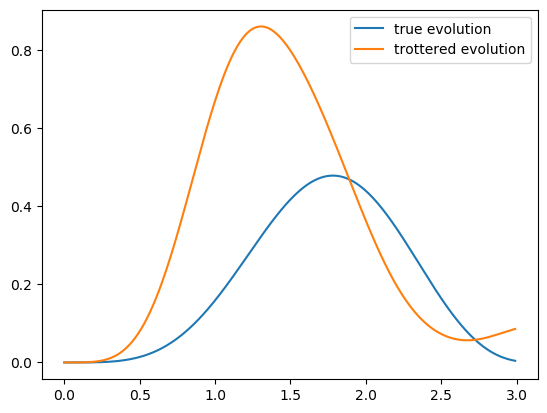

In [204]:
#comparing the two evolutions starting the evolution in |1100> ending in |0011>

plt.plot(times, chances_true[:, 12], label="true evolution")
plt.plot(times, chances_trottered[:, 12], label="trottered evolution")
plt.legend()